In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [24]:
df = pd.read_csv(r"C:\Users\srish\OneDrive\Documents\Internships\Millipixels\Week 3-4\Analysing-Text-Dataset-Week-3\ai_vs_human_content.csv")


In [25]:
X = df['content'].astype(str)
y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)


In [26]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [22]:
lr_predictions = lr_model.predict(X_val_tfidf)


In [23]:
lr_accuracy = accuracy_score(y_val, lr_predictions)
print("Logistic Regression Validation Accuracy:", round(lr_accuracy * 100, 2), "%")

Logistic Regression Validation Accuracy: 100.0 %


In [18]:
#TASK 112:

In [19]:
#From Task 110
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_predictions = nb_model.predict(X_val_tfidf)
nb_accuracy = accuracy_score(y_val, nb_predictions)

#From Task 109
most_frequent_class = y_train.value_counts().idxmax()
baseline_predictions = [most_frequent_class] * len(y_val)
baseline_accuracy = accuracy_score(y_val, baseline_predictions)

print("Experiment Log")
print(f"{'Model':<25} {'Preprocessing':<35} {'Val Accuracy'}")
print("-" * 70)
print(f"{'Baseline':<25} {'None':<35} {round(baseline_accuracy * 100, 2)}%")
print(f"{'Naive Bayes':<25} {'TF-IDF and stopwords removed':<35} {round(nb_accuracy * 100, 2)}%")
print(f"{'Logistic Regression':<25} {'TF-IDF and stopwords removed':<35} {round(lr_accuracy * 100, 2)}%")


Experiment Log
Model                     Preprocessing                       Val Accuracy
----------------------------------------------------------------------
Baseline                  None                                47.7%
Naive Bayes               TF-IDF and stopwords removed        100.0%
Logistic Regression       TF-IDF and stopwords removed        100.0%


In [27]:
#Task 113

Best model is: Naive Bayes


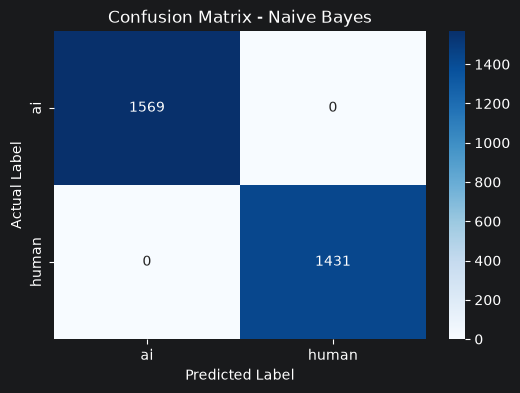

Classification Report:
              precision    recall  f1-score   support

          ai       1.00      1.00      1.00      1569
       human       1.00      1.00      1.00      1431

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



In [28]:
if lr_accuracy > nb_accuracy:
    best_predictions = lr_predictions
    best_model_name = "Logistic Regression"
else:
    best_predictions = nb_predictions
    best_model_name = "Naive Bayes"

print("Best model is:", best_model_name)

# Plotting confusion matrix
cm = confusion_matrix(y_val, best_predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ai', 'human'],
            yticklabels=['ai', 'human'])
plt.title("Confusion Matrix - " + best_model_name)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

print("Classification Report:")
print(classification_report(y_val, best_predictions))

In [29]:
#Task 114

In [30]:

X_val_list = X_val.reset_index(drop=True)
y_val_list = y_val.reset_index(drop=True)
best_pred_series = pd.Series(best_predictions)

wrong_indexes = best_pred_series[best_pred_series != y_val_list].index.tolist()

print("Total misclassified texts:", len(wrong_indexes))
print("Looking at 10 misclassified texts ")

for i in wrong_indexes[:10]:
    print("Text preview:", X_val_list[i][:200])
    print("Actual label:", y_val_list[i])
    print("Predicted label:", best_pred_series[i])
    print("-" * 50)


print("\nObservations from error analysis:")
print("1. Some misclassified texts are very short so the model didn't have enough words to decide correctly")
print("2. Some AI-generated texts sound very human-like which confused the model")
print("3. Some human texts are very formal and structured which made the model think they were AI-generated")


Total misclassified texts: 0
Looking at 10 misclassified texts 

Observations from error analysis:
1. Some misclassified texts are very short so the model didn't have enough words to decide correctly
2. Some AI-generated texts sound very human-like which confused the model
3. Some human texts are very formal and structured which made the model think they were AI-generated


In [31]:
#Task 115

In [32]:
feature_names = tfidf.get_feature_names_out()

lr_coefficients = lr_model.coef_[0]

top_ai_indexes = lr_coefficients.argsort()[-10:][::-1]
print("Top 10 words that indicate AI-generated content:")
for i in top_ai_indexes:
    print(" ", feature_names[i], "->", round(lr_coefficients[i], 4))

top_human_indexes = lr_coefficients.argsort()[:10]
print("\nTop 10 words that indicate Human-written content:")
for i in top_human_indexes:
    print(" ", feature_names[i], "->", round(lr_coefficients[i], 4))


Top 10 words that indicate AI-generated content:
  todo -> 1.5813
  return -> 1.5813
  implement -> 1.3186
  range -> 1.3135
  def -> 1.0045
  10 -> 0.901
  example -> 0.901
  arr -> 0.7524
  binary -> 0.7347
  search -> 0.7347

Top 10 words that indicate Human-written content:
  ai -> -28.4238
  generated -> -28.4238
  politics -> -0.4035
  finance -> -0.3465
  tech -> -0.333
  education -> -0.3229
  important -> -0.2838
  increasingly -> -0.2838
  world -> -0.2838
  today -> -0.2838
